# Email Spam Detection with Machine Learning

This project aims to build a machine learning model that can classify emails/messages as 'spam' or 'ham' (not spam). This is a classic text classification problem.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## 1. Load the Dataset

In [14]:
# Loading the dataset with latin-1 encoding
df = pd.read_csv('../TASK-4 DATASET/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 2. Data Cleaning

In [15]:
# Dropping unnecessary columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

# Renaming columns
df.columns = ['Label', 'Message']
df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
# Checking for duplicates
print(f"Duplicates: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Duplicates: 403


## 3. Exploratory Data Analysis (EDA)

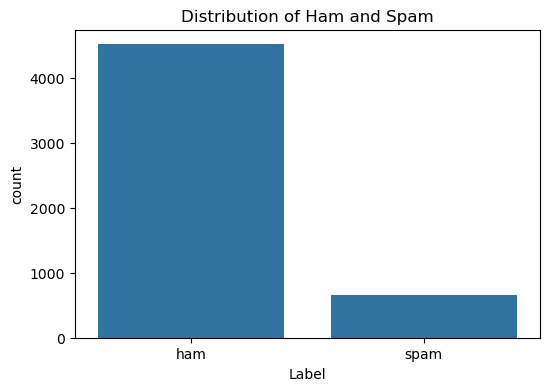

In [17]:
# Visualizing the distribution of labels
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label')
plt.title('Distribution of Ham and Spam')
plt.show()

In [18]:
# Encoding the label
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})
df.head()

,Label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 4. Model Building

In [19]:
# Splitting the data
X = df['Message']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Feature extraction using TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [21]:
# Training the Naive Bayes model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## 5. Model Evaluation

In [22]:
# Predictions
y_pred = model.predict(X_test_tfidf)

# Accuracy and Report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.76      0.86       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



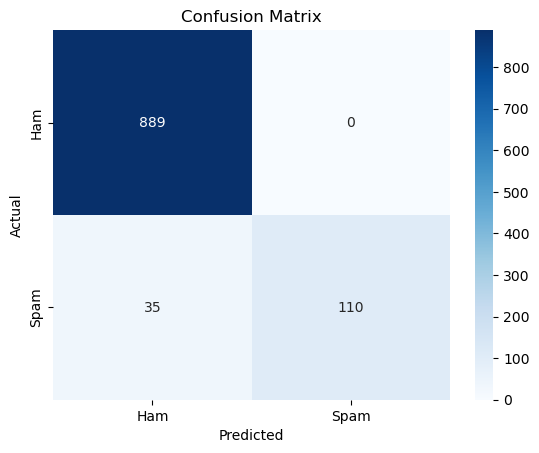

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 6. Testing with Custom Input

In [24]:
def predict_spam(message):
    msg_tfidf = tfidf.transform([message])
    prediction = model.predict(msg_tfidf)
    return 'Spam' if prediction[0] == 1 else 'Ham'

# Example
sample_msg = "Congratulations! You've won a free gift card. Click here to claim."
print(f"Message: {sample_msg}")
print(f"Prediction: {predict_spam(sample_msg)}")

Message: Congratulations! You've won a free gift card. Click here to claim.
Prediction: Spam
